I, Avery Anjard, did not use ChatGPT or any other AI/LLM to assist me on this assessment

2. Read in the gourds data into a DataFrame named gourds and look at the top 5 rows.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gourds = pd.read_csv('gourds.csv')

In [3]:
gourds.head()

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
0,2013,F,154.5 lb,1.0,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,NaN,154.5
1,2013,F,146.5 lb,2.0,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,NaN,146.5
2,2013,F,145.0 lb,3.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,NaN,145.0
3,2013,F,140.8 lb,4.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,NaN,140.8
4,2013,F,139.0 lb,5.5,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.0,NaN,139.0


3. Which country shows up the most frequently in the dataset? Create a visualization (your choice) to show the frequency of appearances for the top 5 countries in terms of number of appearances.

In [6]:
top_gourd_countries = gourds.country.value_counts().head()

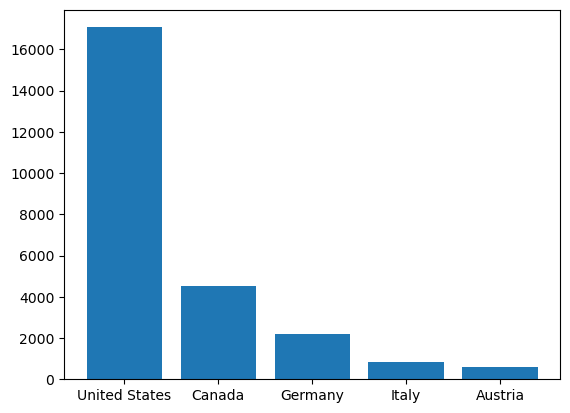

In [7]:
plt.bar(x = top_gourd_countries.index, height = top_gourd_countries)
plt.show()

4. The weight column currently contains a unit ("in" for Long Gourds and "lb" for every other type). Remove the unit from this so that you just have the numeric value and save the result back to the weight column. After doing this, sort the values on the weight column. You should find that the heaviest gourd in the dataset weighs 2702.9 lb. If you cannot find a solution for this question, you can use the weight_bk to answer the questions below that rely on it.

In [11]:
gourds.weight = gourds.weight.str[:-3].astype(float)

In [13]:
gourds.sort_values(by='weight', ascending=False)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk
25730,2021,P,2702.90,1.0,"Cutrupi, Stefano",Radda in Chianti,Tuscany,Italy,Campionato dello Zuccone,1885.5 Werner,Self,514.0,2553.0,NaN,2702.90
9964,2016,P,2624.60,1.0,"Willemijns, Mathias",Deurle,East Flanders,Belgium,Europameisterschaft im Kurbiswiegen,2145 McMullen,1872 Willemijns,496.0,2175.0,NaN,2624.60
22871,2020,P,2593.70,1.0,"Paton, Ian & Stuart",Everton nr. Lymington,England,United Kingdom,Royal Victoria Country Park,"1875 MENDI ""B""",2005 HAIST,502.0,2431.0,NaN,2593.70
22872,2020,P,2551.90,2.0,"Mendi, Ruben",VALTIERRA,Navarre,Spain,Concurso Calabazas Gigantes de Valtierra,2183.7 Mendi 2019,self,485.0,2255.0,NaN,2551.90
16260,2018,P,2528.00,1.0,"Geddes, Steve",Boscawen,New Hampshire,United States,Deerfield Fair,1911 Urena,1803 Gadberry,490.0,2307.0,NaN,2528.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27752,2021,T,0.21,370.0,"Ritter, Leif",Aurora,Colorado,United States,Early Tomatoes,9.44 La Rue,self,NaN,NaN,Domingo,0.21
2143,2013,P,0.15,1681.0,"Llyod, Sue",Woodstock,Connecticut,United States,Woodstock Fair,NaN,NaN,0.0,0.0,NaN,0.15
18703,2018,T,0.14,366.0,"Lindley, Jeremy",Wynne,Arkansas,United States,Operation Pumpkin,NaN,NaN,NaN,NaN,NaN,0.14
22392,2019,W,0.10,289.5,"May, Nico",NaN,Saxony,Germany,Saechsische Meisterschaft im Kurbiswiegen,NaN,NaN,0.0,227.0,NaN,0.10


5. Create a line plot showing the trend in the heaviest gourd by year. What do you notice?

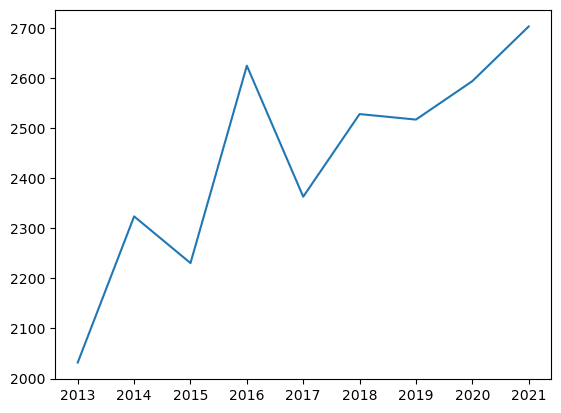

In [16]:
plt.plot(gourds.groupby('year')['weight'].max())
plt.show()

Gourds have generally gotten heavier from 2013 to 2021. However, there was a very large peak in 2016, and several other peaks in other years.

6. Read the type_name.csv dataset into a new DataFrame named type_name. Merge this with gourds to add on type_name column. Which type of gourd is heaviest on average? Create a visualization showing the distribution of gourd weights by type.

In [17]:
type_name = pd.read_csv('type_name.csv')

In [18]:
type_name.head()

,type_id,type_name
0,F,Field Pumpkin
1,P,Giant Pumpkin
2,S,Giant Squash
3,W,Giant Watermelon
4,T,Tomato


In [21]:
gourds = pd.merge(gourds, type_name)

In [32]:
avg_gourd_weight = gourds.groupby('type_name')['weight'].mean().sort_values(ascending=False)

In [33]:
avg_gourd_weight

type_name
Giant Pumpkin       776.033885
Giant Squash        527.298348
Giant Watermelon    127.149110
Long Gourd           94.567945
Field Pumpkin        79.456309
Tomato                3.176921
Name: weight, dtype: float64

Giant Pumpkin gourds are the heaviest on average.

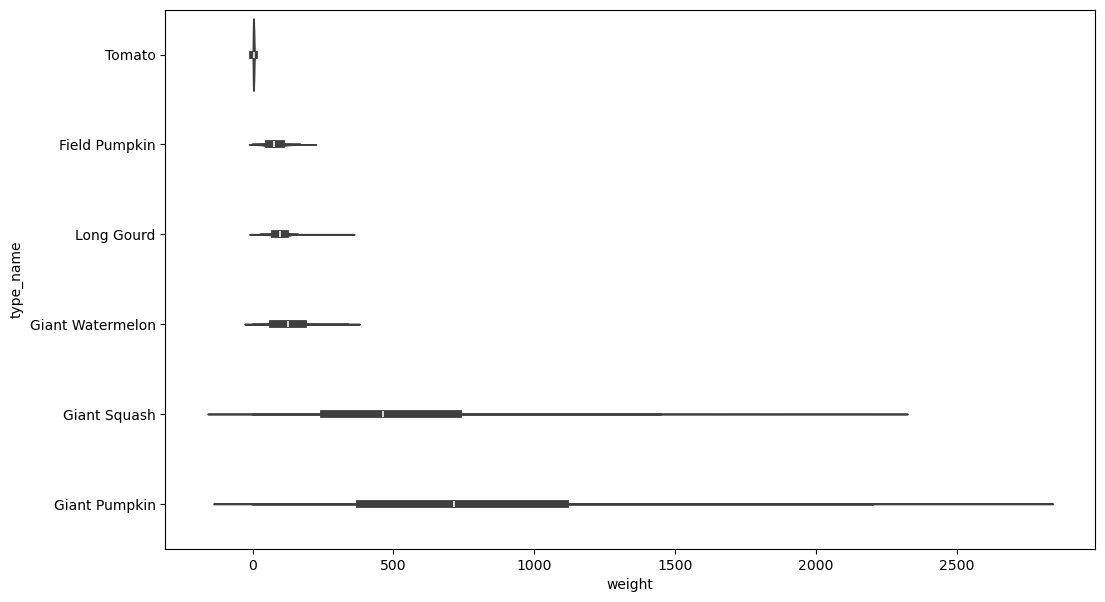

In [114]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=gourds, y='type_name', x='weight', order=avg_gourd_weight.sort_values().index)
plt.show()

7. Create a new column weight_error that contains the amount by which the estimated weight exceeded the actual weight. What is the worst overestimate of a gourd weight? What percentage of gourd weights are overestimated?

In [56]:
gourds['weight_error'] = gourds.est_weight - gourds.weight

In [59]:
gourds.sort_values(by='weight_error', ascending=False).head(1)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
20945,2019,P,316.0,1403.0,"Shenfish, Gary",Littleton,Colorado,United States,Fort Collins Nursery Weigh-off,2170 Daletes,1911 Urena,1132.0,11033.0,NaN,316.0,Giant Pumpkin,10717.0


In [63]:
(len(gourds[gourds.weight_error > 0]) / len(gourds)) * 100

30.06318946128307

8. Create a visualization to compare the estimated weight (est_weight) to the actual weight (weight_lbs). Note that both of these columns are numeric, so choose a type of visualization most appropriate for these data types. What do you notice from your visualization?

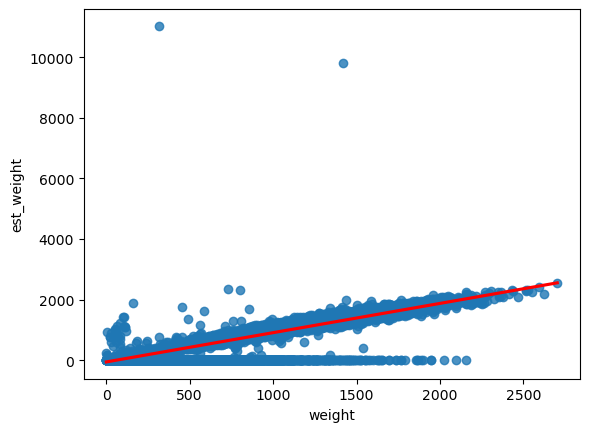

In [67]:
sns.regplot(data=gourds, x='weight', y='est_weight', ci=None, line_kws={"color": "red"})
plt.show()

On average, estimated weights are close to actual weights. However, there are a few major overestimations, and quite a few underestimations (although this might just be missing data).

9. Some growers compete across multiple types of gourd. Which grower has top 10 finishes across the largest number of types of gourds? What is this grower's best finish that shows up in the dataset?

In [73]:
best_growers = gourds[gourds.place <= 10].groupby('grower_name')['type_name'].nunique().sort_values(ascending=False)

In [115]:
best_growers.head()

grower_name
Martin, Margaret & Glen    4
Jutras, Joe                3
Ansems, Fred               3
Tobeck, Cindy              3
Werner, Quinn              3
Name: type_name, dtype: int64

Margaret and Glen Martin have the most top 10 finishes across the largest nuumber of types of gourds.

In [112]:
gourds[gourds.grower_name == best_growers.index[0]].sort_values(by='place').head(1)

,year,type_id,weight,place,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,variety,weight_bk,type_name,weight_error
5496,2014,T,7.45,2.0,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,5.63 Martin uof '13 (big zac),open,NaN,NaN,Big Zac,7.45,Tomato,NaN


Their best finish is 2nd.

10. The seed_mother and pollinator_father give information on the parents for each gourd.

a. How many gourds appear in the seed_mother column at least 100 times?

In [95]:
seed_mothers = gourds.seed_mother.value_counts()

In [109]:
seed_mothers[seed_mothers >= 100]

seed_mother
unknown          277
Unknown          260
2145 McMullen    122
2009 Wallace     104
Name: count, dtype: int64

2, not counting unknown.

b. How many gourds appear in the pollinator_father column at least 100 times?

In [97]:
pollinator_fathers = gourds.pollinator_father.value_counts()

In [110]:
pollinator_fathers[pollinator_fathers >= 100]

pollinator_father
open             2658
Open             2065
self             2020
Self             1875
2009 Wallace      146
2145 McMullen     125
unknown           114
Unknown           100
Name: count, dtype: int64

2, not counting unknown, open, and self.

c. How many gourds have at least 100 offspring that have appeared in the GPC Weighoff? That is, how many gourds appear at least 100 times between the seed_mother and pollinator_father columns combined? Hint: One way you could do this is to create two value_counts Series on the seed_mother and pollinator_father columns and merge them.

In [100]:
gourd_parents = seed_mothers + pollinator_fathers

In [111]:
gourd_parents[gourd_parents >= 100]

1911 Urena        135.0
1985 Miller       158.0
2009 Wallace      250.0
2145 McMullen     247.0
2363 Holland      118.0
Open             2092.0
Self             1876.0
Unknown           360.0
open             2685.0
self             2022.0
unknown           391.0
Name: count, dtype: float64

5, not counting unknown, open, and self.